
# ICS - Travaux Pratiques 9

30.04.25


<font color=grey>_Ce 9e TP se concentre sur les différents algorithmes de recherche et de tri que nous avons vus en cours. Nous en profiterons pour aborder d'autres algorithmes similaire, ou de créer nos propres algorithmes sur la base d'instructions. Bien que cette série soit sous forme de Jupyter Notebook, vous devrez résoudre une partie des exercices sur papier._ 

_Note : ne vous sentez pas obligé.e.s de finir la série pendant la séance! Celle-ci est conçue de manière à ce que vous gardiez certains exercices pour vos révisions._ </font>

In [5]:
import numpy as np
import matplotlib.pyplot as plt

***

## Exercice 0 : Echauffement

Ordonner (sans justification) les fonctions suivantes par ordre de croissance, en
groupant ensemble les fonctions qui ont le même ordre de croissance. Vous pouvez
vérifier vos réponses en dessinant le graphes de ces fonctions à l'aide du module
`matplotlib` comme au TP précédent.

$$n \log_2 (n), \; (\log_2(n))^2, \; n, \; n^2, \; 2^n, \; 1000n^{10}, \; \sqrt{n}, \;
(\log_2(n^2)), \; \sqrt{n} \log_2 (n), \; \log_2 (n).$$

$$\log_2(n), \; \log_2(n^2), \; (\log_2(n))^2, \; n, \; n\log_2(n), \; \sqrt{n}, \; \sqrt{n}\log_2(n), \; n^2, \; 1000n^{10}, \; 2^n \; FAUX =>$$
$$\log_2(n), \; \log_2(n^2), \; \sqrt{n}, \; (\log_2(n))^2, \; \sqrt{n}\log_2(n), \; n, \; n\log_2(n), \; n^2, \; 1000n^{10}, \; 2^n$$


<font color=grey> S'aider des affirmations suivantes :
- Si $\lim_{n \rightarrow \infty}\frac{g(n)}{f(n)} = +\infty$ alors $f(n) = \mathcal{O}(g(n))$ 
- Si $\lim_{n \rightarrow \infty}\frac{f(n)}{g(n)} = 0$ alors  $f(n) = \mathcal{O}(g(n))$
</font>

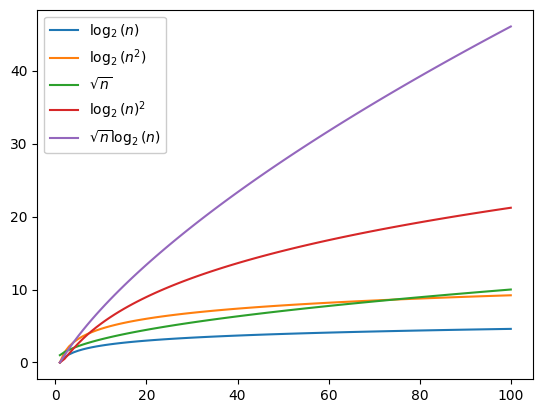

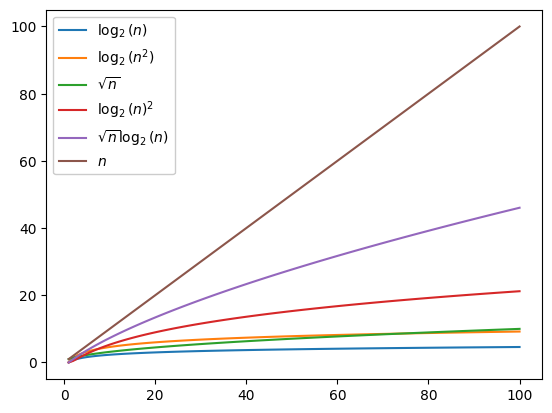

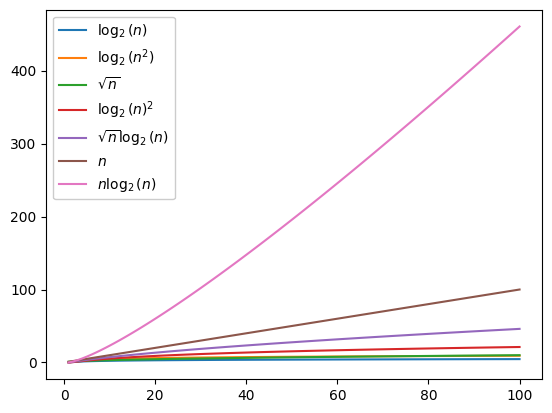

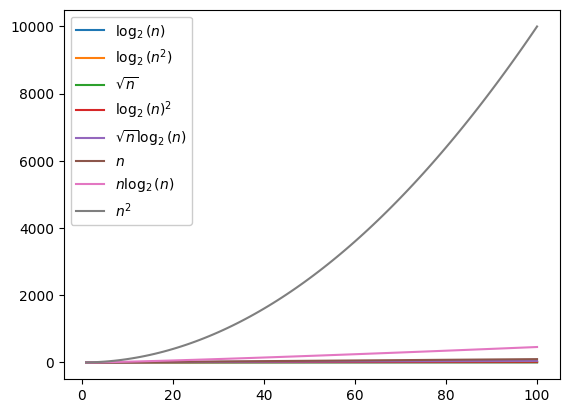

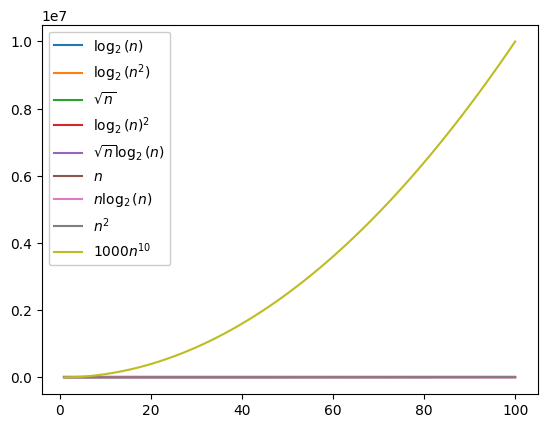

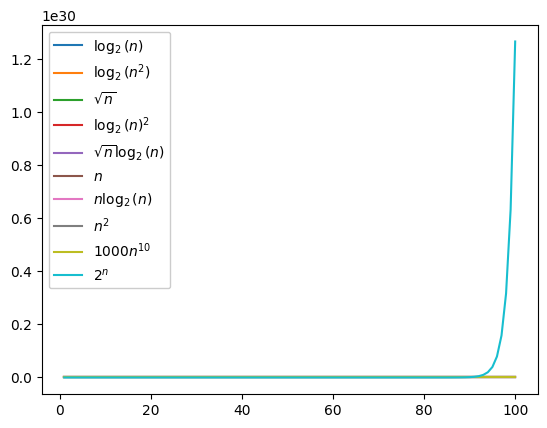

In [75]:
nbre = 100

n = np.linspace(1, 100, nbre)
y = np.arange(1, 15, .1)

def log_n():
    plt.plot(n, np.log(n), label=r"$\log_2(n)$")
    plt.plot(n, np.log(n ** 2), label=r"$\log_2(n^2)$")
    plt.plot(n, np.sqrt(n), label=r"$\sqrt{n}$")
    plt.plot(n, np.log(n) ** 2, label=r"$\log_2(n)^2$")
    plt.plot(n, np.sqrt(n) * np.log(n), label=r"$\sqrt{n}\log_2(n)$")

def o_n():
    log_n()
    plt.plot(n, n, label=r"$n$")

def o_n_log_n():
    o_n()
    plt.plot(n, n * np.log(n), label=r"$n\log_2(n)$")

def o_n2():
    o_n_log_n()
    plt.plot(n, n ** 2, label=r"$n^2$")

def o_n10():
    o_n2()
    plt.plot(n, 1000 * n ** 2, label=r"$1000n^{10}$")


def o_exp_n():
    o_n10()
    plt.plot(n, 2 ** n, label=r"$2^n$")


log_n()
plt.legend(loc="upper left", framealpha=1)
plt.show()

o_n()
plt.legend(loc="upper left", framealpha=1)
plt.show()

o_n_log_n()
plt.legend(loc="upper left", framealpha=1)
plt.show()

o_n2()
plt.legend(loc="upper left", framealpha=1)
plt.show()

o_n10()
plt.legend(loc="upper left", framealpha=1)
plt.show()

o_exp_n()
plt.legend(loc="upper left", framealpha=1)
plt.show()


***

## Exercice 1 : Recherche de la première occurence d'un nombre

On se propose d'écrire un algorithme qui prend en entrée une liste de nombres `L` **triée** et une valeur `x`, et retourne l'indice de la **première occurrence** de `x` dans la liste. Si aucun élément de valeur `x` n'est dans la liste, l'algorithme doit retourner `None`.

Par exemple, pour la liste `[10, 20, 20, 20, 20, 30, 30]` et la valeur `20` en entrée, l'algorithme doit retourner l'indice `1` (alors que `recherche_binaire` retournerait l'indice `3`).

- Implémentez en Python l'algorithme suivant, qui résoud ce problème:
	- Appeler `recherche_binaire(L, x)`
	- Si cet appel retourne un indice `i`, parcourir `L` en allant à gauche depuis `i` jusqu'à trouver un élément différent de `x` (ou jusqu'à arriver au début de la liste)
	- Retourner l'indice `i` de la première occurrence de `x` dans `L`.
    Quel est l'ordre de croissance du temps de parcours de cet algorithme au pire des cas, en fonction de la taille $n$ de la liste `L`?

- Donnez un autre algorithme qui résoud le même problème mais dont le temps de parcours au pire des cas est de l'ordre de $\log_2(n)$. <font color=grey> Pour cela, aidez-vous de la structure de l'algorithme de recherche binaire. Comment être sûr.e que le nombre trouvé est le premier nombre de la liste?</font>
- Utilisez la librarie `Matplotlib` pour comparer le temps de parcours de vos deux algorithmes sur des listes de taille $n$, pour $n$ de plus en plus grand. Vous pouvez utiliser des listes qui contiennent une même valeur répétée $n$ fois et rechercher la première occurrence de cette valeur (qui devrait être à l'indice `0`).

In [7]:
# Réponse au point 1.
def recherche_binaire(L, x):
    '''
    Entrée: nombre x, liste L de nombres triée
    Sortie: i t.q. L[i]=x s'il existe, None sinon
    '''
    n = len(L)
    bas = 0
    haut = n-1
    
    while haut >= bas:
        milieu = (bas + haut)//2
        if L[milieu] == x:
            return milieu
        elif L[milieu] > x:
            haut = milieu - 1
        else:
            bas = milieu + 1
            

def recurrence_lineaire(L, x):
    '''
    Entrée: nombre x, liste L de nombres triée
    Sortie: i t.q. L[i]=x, première récurrence, s'il existe, None sinon
    '''
    i = recherche_binaire(L, x)
    
    if i == None:
        return None
    
    for index in range(i-1, -1, -1):
        if L[i] > L[index]:
            return index + 1


L = list(range(10, 110, 10))
L2 = [1, 2, 3, 3, 3, 4, 5, 6, 7, 8, 10]
print(recurrence_lineaire(L, 3), recurrence_lineaire(L2, 3))

None 2


In [8]:
# Réponse au point 2.
def recurrence_logarithmique(L, x):
    '''
    Entrée: nombre x, liste L de nombres triée
    Sortie: i t.q. L[i]=x, première récurrence s'il existe, None sinon
    '''
    n = len(L)
    bas = 0
    haut = n-1
    
    while haut >= bas:
        milieu = (bas + haut)//2
        if L[milieu] == x:
            if L[milieu-1] < x or milieu == 0:
                return milieu
            else:
                haut = milieu - 1
        elif L[milieu] > x:
            haut = milieu - 1
        else:
            bas = milieu + 1
            
            
recurrence_logarithmique(L2, 3), recurrence_logarithmique(L2, 1), recurrence_logarithmique(L2, 10)

(2, 0, 10)

In [60]:
# Réponse au point 3.
import time
import random

len_ = [10, 100, 1000, 10000, 100000, 1000000, 10000000]
N = 1000
a = np.random.rand(N)

def test(nbres):
    for nbre in nbres:
        L = [random.randint(1, 20) for _ in range(nbre)]
        L.sort()
        x = 1
        
        print(f"********** (len(L) = {nbre}) **********")

        t0 = time.perf_counter_ns()
        recurrence_lineaire(L, x)
        t1 = time.perf_counter_ns()
        print(f"L'appel 'recurrence_lineaire(L, nbre)' a pris ", t1 - t0, " seconde(s).")

        t0 = time.perf_counter_ns()
        recurrence_logarithmique(L, x)
        t1 = time.perf_counter_ns()
        print(f"L'appel 'recurrence_logarithmique(L, nbre)' a pris ", t1 - t0, " seconde(s).", end="\n\n")
        

test(len_)

********** (len(L) = 10) **********
L'appel 'recurrence_lineaire(L, nbre)' a pris  7700  seconde(s).
L'appel 'recurrence_logarithmique(L, nbre)' a pris  3800  seconde(s).

********** (len(L) = 100) **********
L'appel 'recurrence_lineaire(L, nbre)' a pris  6000  seconde(s).
L'appel 'recurrence_logarithmique(L, nbre)' a pris  4100  seconde(s).

********** (len(L) = 1000) **********
L'appel 'recurrence_lineaire(L, nbre)' a pris  13300  seconde(s).
L'appel 'recurrence_logarithmique(L, nbre)' a pris  4900  seconde(s).

********** (len(L) = 10000) **********
L'appel 'recurrence_lineaire(L, nbre)' a pris  67100  seconde(s).
L'appel 'recurrence_logarithmique(L, nbre)' a pris  10600  seconde(s).

********** (len(L) = 100000) **********
L'appel 'recurrence_lineaire(L, nbre)' a pris  348200  seconde(s).
L'appel 'recurrence_logarithmique(L, nbre)' a pris  7200  seconde(s).

********** (len(L) = 1000000) **********
L'appel 'recurrence_lineaire(L, nbre)' a pris  3132900  seconde(s).
L'appel 'recurre

## Exercice 2 : Fibonacci

En cours, nous avons présenté l'implémentation suivante d'un algorithme calculant le $N^e$ nombre de la suite de Fibonacci. 


In [ ]:
def fib_rec(n):
    if n == 0:
        return 0
    if n == 1:
        return 1
    return fib_rec(n-1) + fib_rec(n-2)


Cet algorithme ayant un temps de parcours asymptotiquement exponentiel, nous souhaiterions l'améliorer. 

Réécrire l'algorithme précédent afin que sa complexité devienne linéaire $(\Theta(n))$.


     


<font color=grey>Indice : utilisez un algorithme itératif, et non pas récursif ! De quelles éléments de la suite avez-vous besoin pour construire l'élément</font> $f_n$?


In [59]:
# Votre réponse ici
def fib_lin(n):
    if n == 0:
        return 0
    if n in [1, 2]:
        return 1
    elif n > 2:
        fib_n = 0
        fib_1 = 1
        fib_2 = 1
        
        for _ in range(2, n):
            fib_n = fib_1 + fib_2
            fib_1, fib_2 = fib_n, fib_1

        return fib_n
    

for i in range(30, 1000):
    t0 = time.perf_counter_ns()
    fibi = fib_lin(i)
    t1 = time.perf_counter_ns()
    
    print(f"fib({i}) = {fibi} ({t1-t0} ns)")

fib(30) = 832040 (13500 ns)
fib(31) = 1346269 (8600 ns)
fib(32) = 2178309 (7200 ns)
fib(33) = 3524578 (6500 ns)
fib(34) = 5702887 (4900 ns)
fib(35) = 9227465 (4900 ns)
fib(36) = 14930352 (4900 ns)
fib(37) = 24157817 (4900 ns)
fib(38) = 39088169 (5500 ns)
fib(39) = 63245986 (5400 ns)
fib(40) = 102334155 (5500 ns)
fib(41) = 165580141 (5600 ns)
fib(42) = 267914296 (5700 ns)
fib(43) = 433494437 (5700 ns)
fib(44) = 701408733 (5800 ns)
fib(45) = 1134903170 (6100 ns)
fib(46) = 1836311903 (5900 ns)
fib(47) = 2971215073 (6300 ns)
fib(48) = 4807526976 (6200 ns)
fib(49) = 7778742049 (6400 ns)
fib(50) = 12586269025 (6400 ns)
fib(51) = 20365011074 (6700 ns)
fib(52) = 32951280099 (6600 ns)
fib(53) = 53316291173 (6800 ns)
fib(54) = 86267571272 (6900 ns)
fib(55) = 139583862445 (6900 ns)
fib(56) = 225851433717 (7000 ns)
fib(57) = 365435296162 (7000 ns)
fib(58) = 591286729879 (7400 ns)
fib(59) = 956722026041 (7300 ns)
fib(60) = 1548008755920 (7500 ns)
fib(61) = 2504730781961 (7500 ns)
fib(62) = 40527395

***

## Exercice 3 : compréhension des algorithmes de tri

- Simulez à la main le parcours de `tri_par_selection` sur la liste ci-dessous en affichant le contenu de la liste à la fin de chaque itération de la boucle `for` extérieure. Vérifiez votre réponse en  appelant `tri_par_selection` sur la liste en entrée dans la cellule ci-dessous (et en insérant une instruction `print` dans le code).

    Essayez d'implémenter l'algorithme sans utiliser vos notes de cours!
	
    `[7, 2, 13, -5, -3, 17, 8, 24, -11, 1]`
	
- Même question pour `tri_par_insertion`.

In [43]:
# Réponse au point 1.
def tri_par_selection(L):
    for i in range(len(L)):
        i_min = i
        for k in range(i, len(L)):
            if L[k] < L[i_min]:
                i_min = k
        L[i], L[i_min] = L[i_min], L[i]
    return L


L = [7, 2, 13, -5, -3, -17, 8, 24, -11, 1]

tri_par_selection(L)

[-17, -11, -5, -3, 1, 2, 7, 8, 13, 24]

In [44]:
# Réponse au point 2.
def tri_par_insertion(L):
    for i in range(1, len(L)):
        for k in range(i, -1, -1):
            if L[k] < L[k-1]:
                L[k], L[k-1] = L[k-1], L[k]
            else:
                break
    return L


tri_par_insertion(L)

[-17, -11, -5, -3, 1, 2, 7, 8, 13, 24]

***

## Exercice 4 : tri à bulles

Le **tri à bulles** (bubble sort) fonctionne de la manière suivante:

Il prend en entrée une liste `L` de taille $n$. Il parcourt la liste $n$ fois. A chaque parcours, dès qu'il rencontre deux éléments adjacents de la liste qui sont dans le mauvais ordre, c'est-à-dire `L[i], L[i+1]` tels que `{L[i] > L[i+1]`, il les échange.

On appelle cet algorithme tri à bulles car à chaque parcours de la liste, le plus grand élément (restant) se déplace vers la fin de la liste comme une bulle qui remonte à la surface de l'eau.

- Observez une simulation du tri à bulles sur l'un des sites proposés en cours, par exemple https://visualgo.net/bn/sorting, pour comprendre exactement comment fonctionne l'algorithme.
- Donnez l'algorithme du tri à bulles en Python. N'oubliez pas de tester votre code sur de petites listes.
- Quel est le temps de parcours du tri à bulles? -> $(T(n) \; = \; n^2)$


In [45]:
# Réponse au point 2.
def tri_a_bulle(L):
    n = len(L)
    for _ in range(n):
        for i in range(n-1):
            if L[i] > L[i+1]:
                L[i], L[i+1] = L[i+1], L[1]
    return L


tri_a_bulle(L)

[-17, -11, -5, -3, 1, 2, 7, 8, 13, 24]

***

## Exercice 5 : exercice d'examen

<font color=greblueen> Chaque semaine, je vous propose un exercice sans corrigé détaillé mais en vous indiquant la réponse finale. Ce sera donc à vous de faire l'effort de résoudre ce problème à l'aide des ressources à disposition : vos notes de cours, les forums sur internet ou même ChatGPT du moment que vous faites l'effort de comprendre le code que vous fournit ce Chatbot! 

Pour résoudre cet exercice, je vous conseille de discuter avec vos camarades.</font>

On donne ci-dessous un algorithme de tri, auquel nous avons rajouté l’instruction
`print(f"{i}e element: {L}")`.

In [50]:
def mafonction (L):
    n = len (L)
    for i in range (n-1,-1,-1):
        j = i
        while j < n-1 and L[j] > L[j+1]:
            L[j], L[j+1] = L[j+1], L[j]
            j += 1
        print (f"{i}e element : {L}")

L = [7, 2, 13, -5, -3, -17, 8, 24, -11, 1]

mafonction(L), mafonction([1, 2, 3, 4])

9e element : [7, 2, 13, -5, -3, -17, 8, 24, -11, 1]
8e element : [7, 2, 13, -5, -3, -17, 8, 24, -11, 1]
7e element : [7, 2, 13, -5, -3, -17, 8, -11, 1, 24]
6e element : [7, 2, 13, -5, -3, -17, -11, 1, 8, 24]
5e element : [7, 2, 13, -5, -3, -17, -11, 1, 8, 24]
4e element : [7, 2, 13, -5, -17, -11, -3, 1, 8, 24]
3e element : [7, 2, 13, -17, -11, -5, -3, 1, 8, 24]
2e element : [7, 2, -17, -11, -5, -3, 1, 8, 13, 24]
1e element : [7, -17, -11, -5, -3, 1, 2, 8, 13, 24]
0e element : [-17, -11, -5, -3, 1, 2, 7, 8, 13, 24]
3e element : [1, 2, 3, 4]
2e element : [1, 2, 3, 4]
1e element : [1, 2, 3, 4]
0e element : [1, 2, 3, 4]


(None, None)

- Sans exécuter ce code, saurez-vous dire qu'affichent les instructions suivantes? -> à chaque loop, on va trier de façon croissante une sous liste `L_i = L[i:]`.

    `L = [1, 3, 0, -6, 100 , -1]`

    `mafonction (L)`

- Quel algorithme vu en cours fonctionne selon le même principe que celui-ci? -> tri par insertion

- Quel est le temps de parcours de `mafonction()`? Justifiez brièvement votre réponse et
utilisez la notation de Landau. $\Theta(n^2)$

- Quelle propriété satisfait l'instance pour laquelle le temps de parcours est minimal? -> liste décroissante, triée FAUX => liste croissante
- Que vaut celui-ci dans le meilleur des cas? Justifiez brièvement votre réponse et utilisez la notation de Landau. -> $\Theta(n)$, car chaque boucle while va prendre un étape puisque la condition n'est pas respectée, car la liste est déjà triée.